In [1]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
import scipy.ndimage

os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [2]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
E1 = 1000
E2 = 1000

In [5]:
# x_train = np.load('Train_3D_256_256_128_FOV_norm_data.npz')['Train']
# x_train = np.transpose(x_train, (3, 0, 1, 2))
# vol_shape = x_train.shape[1:]
# print('train vol_shape:', vol_shape)
# print('train shape:', x_train.shape)

In [6]:
# 画像を読み込み
x_train = np.load('CT_Train_NoBed.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))

# 新しいボリュームのサイズ (各軸を半分にする)
new_shape = tuple([dim // 2 for dim in x_train.shape[1:]])

# サイズを半分に縮小
x_train_resized = np.zeros((x_train.shape[0], *new_shape))  # 新しい形に合わせて初期化

for i in range(x_train.shape[0]):
    # 各画像を縮小
    x_train_resized[i] = scipy.ndimage.zoom(x_train[i], (0.5, 0.5, 0.5), order=3)
print('Resized train vol_shape:', x_train_resized.shape[1:])
print('Resized train shape:', x_train_resized.shape)

Resized train vol_shape: (64, 128, 128)
Resized train shape: (59, 64, 128, 128)


In [7]:
x_train = x_train_resized


In [8]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [9]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 64, 128, 128])
Fixed Images Shape: torch.Size([2, 1, 64, 128, 128])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 64, 128, 128])
Zero Gradient Shape: (2, 64, 128, 128, 3)


In [10]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

def MSE_Loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    return mse

In [11]:
import torch
import torch.nn.functional as F

def gaussian_pyramid(img, num_levels=4):
    pyr = [img]
    for i in range(num_levels - 1):
        img = F.interpolate(img, scale_factor=0.5, mode='trilinear', align_corners=False)
        pyr.append(img)
    return pyr

def laplacian_pyramid(img, num_levels=4):
    pyr = gaussian_pyramid(img, num_levels)
    lap_pyr = []
    for i in range(num_levels - 1):
        up = F.interpolate(pyr[i + 1], size=pyr[i].shape[2:], mode='trilinear', align_corners=False)
        lap_pyr.append(pyr[i] - up)
    lap_pyr.append(pyr[-1])
    return lap_pyr

def laplacian_pyramid_loss(img1, img2, num_levels=4):
    pyr1 = laplacian_pyramid(img1, num_levels)
    pyr2 = laplacian_pyramid(img2, num_levels)
    
    loss = 0.0
    for l1, l2 in zip(pyr1, pyr2):
        loss += F.mse_loss(l1, l2)
    
    return loss

In [12]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]

In [13]:
model3D_3 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
model3D_3.to(device)
optimizer = optim.Adam(model3D_3.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
6
7
64
128
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
11
11
11
[32, 64, 64]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [14]:
# from tqdm.notebook import tqdm
# transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# # エポック数とアーリーストッピングの設定
# epochs = 10000
# patience = 500  # ロス改善が見られないエポック数でアクション
# min_delta = 0.02  # ロス改善の最小差
# best_loss = float('inf')
# no_improve_epochs = 0

# # ロスや他のメトリクスを記録するリスト
# losses = []
# shift_range = 3  # 初期位置ずれ範囲

# for epoch in tqdm(range(epochs)):
#     # 学習データのバッチを取得
#     train_batch, _ = next(train_generator)
#     moving_images = torch.tensor(train_batch[0], dtype=torch.float32)

#     # 入力データのリサイズ（64x128x128に統一）
#     # moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
#     moving_images = moving_images.to(device)
 
#     # 位置ずれを生成する
#     shift_x = torch.randint(-shift_range, shift_range + 1, (1,)).item()
#     shift_y = torch.randint(-shift_range, shift_range + 1, (1,)).item()
#     shift_z = torch.randint(-shift_range, shift_range + 1, (1,)).item()

#     # 位置ずれフィールドを作成
#     displacement_field = torch.zeros((moving_images.size(0), 3, *moving_images.shape[2:]), dtype=torch.float32).to(device)
#     displacement_field[:, 0, :, :, :] += shift_x  # x方向のシフト
#     displacement_field[:, 1, :, :, :] += shift_y  # y方向のシフト
#     displacement_field[:, 2, :, :, :] += shift_z  # z方向のシフト
#     print("LL_Moving", displacement_field.shape)  # (1, 3, 64, 128, 128)

#         # 位置をずらした画像を生成
#     moving_images2 = transformer(moving_images, displacement_field)

#     # 勾配を初期化
#     optimizer.zero_grad()

#     # 順伝播
#     transformed_image, Vec = model3D_3(moving_images, moving_images2)

#     # 損失を計算
#     # loss = MSE_Loss(torch.norm(displacement_field, dim=-1), torch.norm(Vec, dim=-1))
#     loss = MSE_Loss(displacement_field, Vec)
#     #loss = MSE_Loss(moving_images2, transformed_image)

#     # 逆伝播
#     # loss.backward
#     import time
#     start_time = time.time()
#     loss.backward()
#     # print(f"Backward pass time: {time.time() - start_time} seconds")
#     optimizer.step()
#     torch.save(model3D_3.state_dict(), 'model_VXM_3D_duwl_omomi_kakunin.pth')

#     # エポックごとのロスを保存
#     losses.append(loss.cpu().item())

#     # ベストロスの更新とアーリーストッピングの判断
#     if loss < best_loss - min_delta:
#         best_loss = loss
#         no_improve_epochs = 0
#     else:
#         no_improve_epochs += 1

#     # ロスが改善しない場合の処理
#     if no_improve_epochs >= patience:
#         if shift_range < 10:  # 位置ずれの範囲を広げる
#             shift_range += 1
#             print(f"Loss stagnated for {patience} epochs. Increasing shift range to ±{shift_range} pixels.")
#             no_improve_epochs = 0  # 再度改善の監視を開始
#         else:
#             print(f"Loss did not improve for {patience} epochs and shift range is max. Stopping early at epoch {epoch+1}.")
#             break  # 学習を停止

#     # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Shift Range: ±{shift_range} pixels")

In [15]:
from tqdm.notebook import tqdm
transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# 3D ガウシアンフィルタを適用する関数
def gaussian_smooth_3d(tensor, kernel_size=5, sigma=1.0):
    """ 3D ガウシアンフィルタで displacement field をスムージング """
    # 3D Gaussian Kernel の作成
    from scipy.ndimage import gaussian_filter
    tensor_np = tensor.cpu().numpy()
    smoothed_np = gaussian_filter(tensor_np, sigma=[0, 0, sigma, sigma, sigma])  # チャネル方向にはフィルタ適用しない
    return torch.tensor(smoothed_np, dtype=torch.float32, device=tensor.device)


# エポック数と最小ロスの設定
epochs = 10000
best_loss = float('inf')
shift_range = 20

# ロスや他のメトリクスを記録するリスト
losses = []
loss_vecs = []
loss_images = []

for epoch in tqdm(range(epochs)):
    # 100エポックごとにshift_rangeを増やす
    if epoch % 1000 == 0 and epoch > 0:
        shift_range += 1
        print(f"Epoch {epoch}: Increasing shift range to ±{shift_range} pixels.")

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)

    # 画像サイズを設定
    B, D, H, W = 2, 8, 16, 16  # バッチサイズと画像の次元

    # displacement_field をボクセルごとにランダムに作成
    displacement_field = (torch.rand((B, 3, D, H, W), dtype=torch.float32) * 2 - 1) * shift_range
    displacement_field = displacement_field.to(device)

    # 3D Gaussian Smoothing を適用
    displacement_field = gaussian_smooth_3d(displacement_field, sigma=2.0)
    displacement_field = torch.nn.functional.interpolate(displacement_field, size=(64,128,128), mode='trilinear', align_corners=False)

    # 位置をずらした画像を生成
    moving_images2 = transformer(moving_images, displacement_field)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, Vec = model3D_3(moving_images, moving_images2)

    # 損失を計算
    loss_vec = MSE_Loss(displacement_field, Vec) * 0.01
    # loss_vec = MSE_Loss(displacement_field, Vec) 
    loss_image = MSE_Loss(moving_images2, transformed_image)

    loss = loss_vec + loss_image

    # 逆伝播
    loss.backward()
    optimizer.step()

    # モデルを保存
    torch.save(model3D_3.state_dict(), 'model_VXM_3D_duwl_omomi_tanomu.pth')

    # エポックごとのロスを保存
    losses.append(loss.cpu().item())
    loss_vecs.append(loss_vec.cpu().item())
    loss_images.append(loss_image.cpu().item())
    
    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, loss_vec: {loss_vec:.4f}, loss_image: {loss_image:.4f}, Shift Range: ±{shift_range} pixels")


  0%|          | 0/10000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_20740\3622883353.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)


LL_Moving tensor(0.2361, device='cuda:0')
HH_Moving tensor(7.7307e-12, device='cuda:0')
LL_Fixed tensor(0.2339, device='cuda:0')
HH_Fixed tensor(4.5475e-12, device='cuda:0')
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 1/10000, Loss: 0.0119, loss_vec: 0.0084, loss_image: 0.0036, Shift Range: ±20 pixels
LL_Moving tensor(0.1668, device='cuda:0')
HH_Moving tensor(4.8885e-12, device='cuda:0')
LL_Fixed tensor(0.1648, device='cuda:0')
HH_Fixed tensor(1.9327e-12, device='cuda:0')
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 2/10000, Loss: 0.0097, loss_vec: 0.0074, loss_image: 0.0023, Shift Range: ±20 pixels
LL_Moving tensor(0.2296, device='cuda:0')
HH_Moving tensor(8.4128e-12, device='cuda:0')
LL_Fixed tensor(0.2267, device='cuda:0')
HH_Fixed tensor(7.6170e-12, device='cuda:0')
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 3/10000, Loss: 0.0096, loss_vec: 0.0066, loss_image: 0.0031, Shift Range: ±20 pixels
LL_Movi

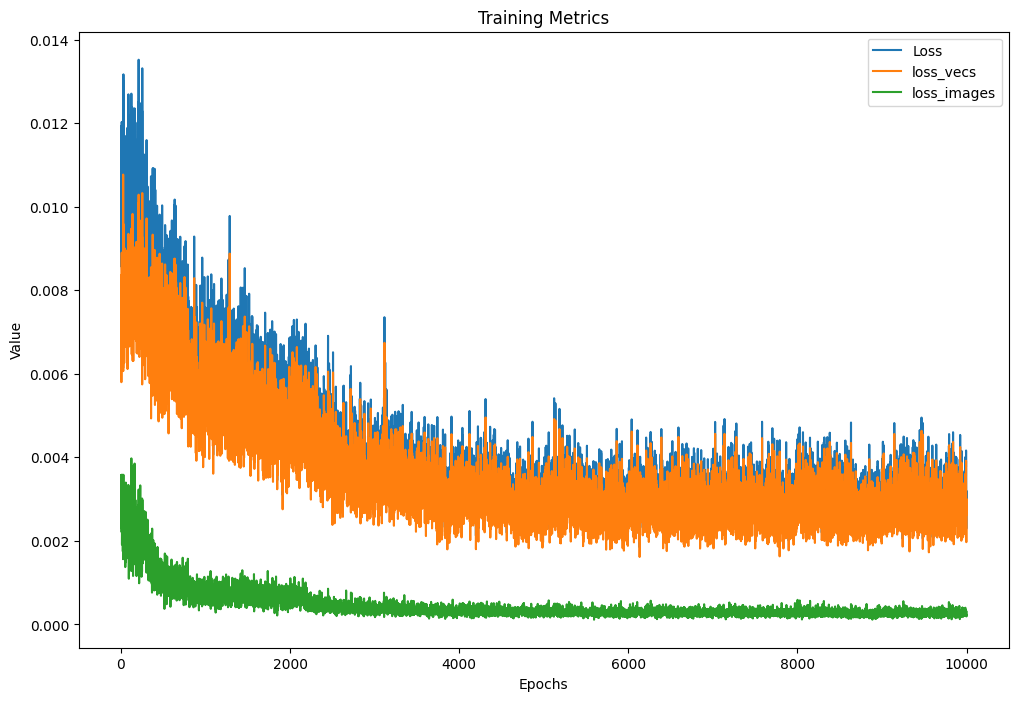

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
epochs_range = range(1, epoch + 1)  # `epoch + 2` を `epoch + 1` に変更

# 損失、MSE、勾配をプロット
epochs_range = range(1,  epoch+2)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, losses, label='Loss')
plt.plot(epochs_range, loss_vecs, label='loss_vecs')
plt.plot(epochs_range, loss_images, label='loss_images')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [17]:
    # 画像サイズを設定
    B, D, H, W = 2, 8, 16, 16  # バッチサイズと画像の次元

    # displacement_field をボクセルごとにランダムに作成
    displacement_field = (torch.rand((B, 3, D, H, W), dtype=torch.float32) * 2 - 1) * shift_range
    displacement_field = displacement_field.to(device)

    # 3D Gaussian Smoothing を適用
    displacement_field = gaussian_smooth_3d(displacement_field, sigma=2.0)
    displacement_field = torch.nn.functional.interpolate(displacement_field, size=(64,128,128), mode='trilinear', align_corners=False)

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# model3D_7 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
# model3D_7.to(device)
# optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

# 学習済みモデルが既にある場合
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_omomi_hukaku.pth', map_location=device))
model3D_3.load_state_dict(torch.load("D:\Yamato\model_VXM_3D_duwl_omomi_tanomu.pth", map_location=device))
CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7 = model3D_3
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    # fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)

    moving_images = moving_images.to(device)
    # fixed_images = fixed_images.to(device)    

    moving_images2 = transformer(moving_images, displacement_field)
    
    transformed_image, pos_flow= model3D_3(moving_images, moving_images2)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = moving_images2[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
LL_Moving tensor(0.1573, device='cuda:0')
HH_Moving tensor(-2.9559e-12, device='cuda:0')
LL_Fixed tensor(0.1512, device='cuda:0')
HH_Fixed tensor(-2.2737e-12, device='cuda:0')
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])


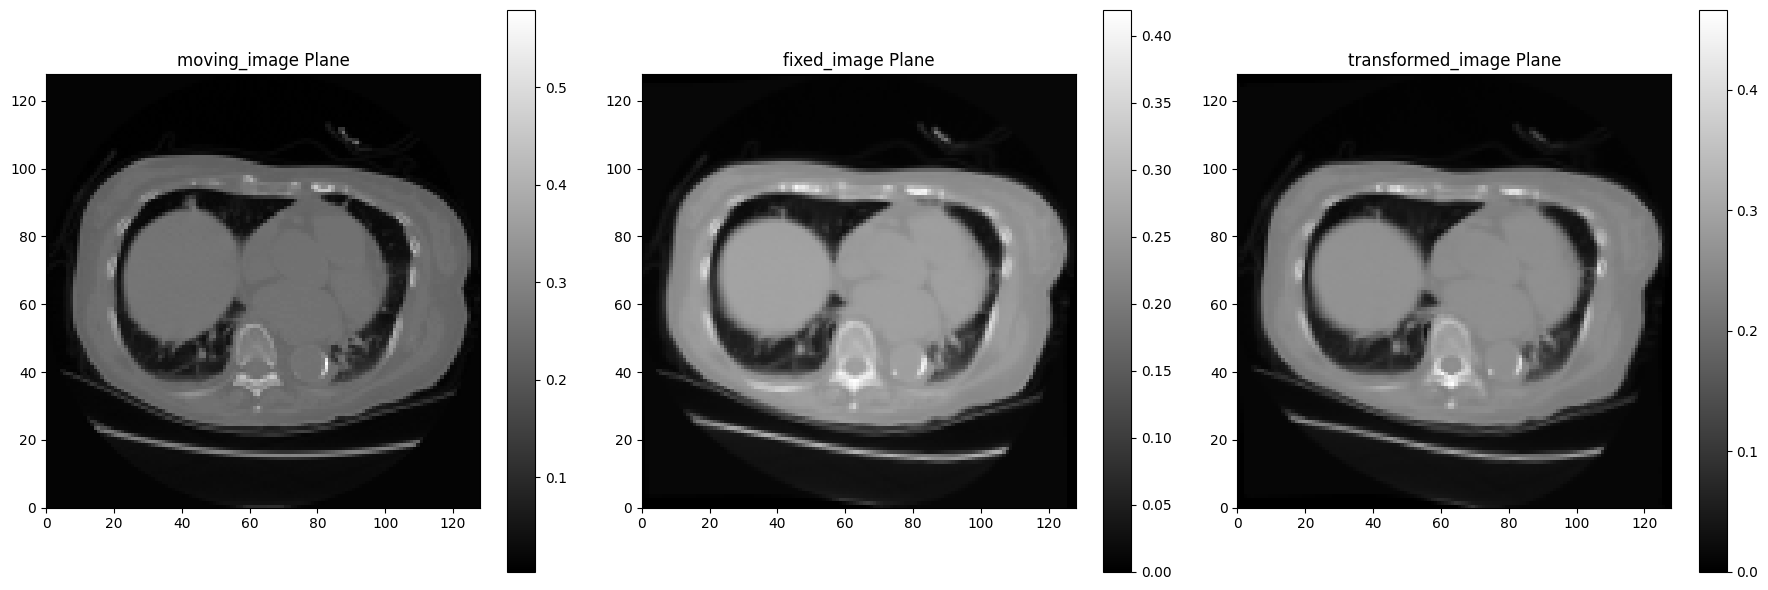

In [20]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 40

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

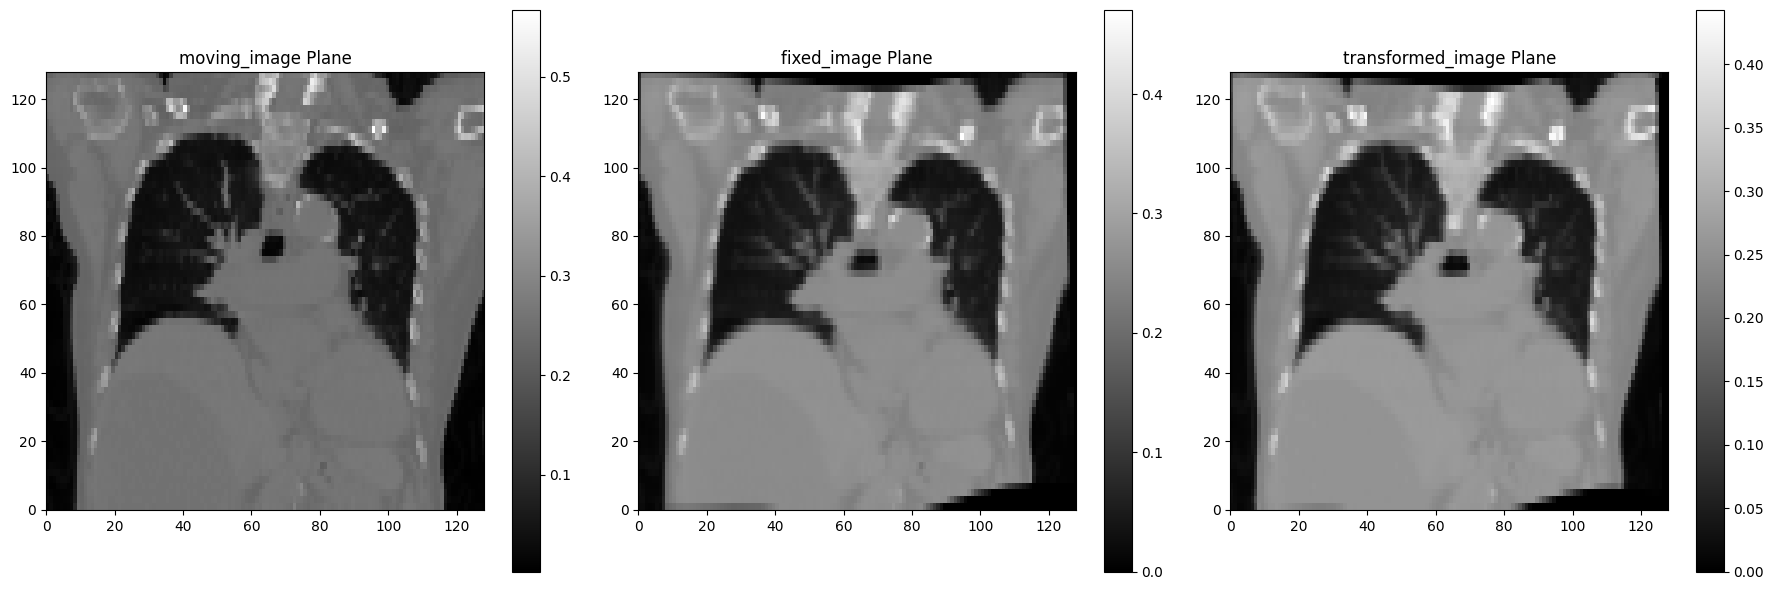

In [21]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 64

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, :, i, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, :, i, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, :, i, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [20]:
imsave('moving_image_Tu.tif', moving_image)
imsave('fixed_image_Tu.tif', fixed_image)
imsave('transformed_image_Tu.tif', transformed_image)

C:\Users\user\AppData\Local\Temp\ipykernel_6472\4264901645.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moving_image_Tu.tif', moving_image)
C:\Users\user\AppData\Local\Temp\ipykernel_6472\4264901645.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('fixed_image_Tu.tif', fixed_image)
C:\Users\user\AppData\Local\Temp\ipykernel_6472\4264901645.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('transformed_image_Tu.tif', transformed_image)


In [32]:
from tqdm.notebook import tqdm

epochs = 10000
losses = []
mses = []
grads = []
laplacian_losses = []
total_loss_values = []

# model3D_5.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_Loss_4_omomi.pth', map_location=device))

for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    
  # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D_3(moving_images, fixed_images)
    
    # 既存の損失を計算
    loss = MSE_Loss(fixed_images, transformed_image)
        
    # 逆伝播
    loss.backward()
    optimizer.step()

    torch.save(model3D_3.state_dict(), 'model_VXM_3D_duwl_omomi3.pth')
        
    # エポックごとのロスを保存
    
    losses.append(loss.cpu().item())    

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

  0%|          | 0/10000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_22392\685687651.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_22392\685687651.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 1/10000, Loss: 0.0186
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 2/10000, Loss: 0.0250
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 3/10000, Loss: 0.0179
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 4/10000, Loss: 0.0194
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 5/10000, Loss: 0.0253
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 6/10000, Loss: 0.0262
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 7/10000, Loss: 0.0155
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 8/10000, Loss: 0.0215
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 9/10000, Loss: 0.0191
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 10/10000, Loss: 0.0173
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128,

KeyboardInterrupt: 

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# model3D_7 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
# model3D_7.to(device)
# optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

# 学習済みモデルが既にある場合
model3D_7.load_state_dict(torch.load('model_VXM_3D_duwl_omomi_tanomu.pth', map_location=device))
model3D_3= model3D_7

CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7 = model3D_3
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)

    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)    

    # moving_images2 = transformer(moving_images, displacement_field)
    
    transformed_image, pos_flow= model3D_3(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
LL_Moving tensor(0.1573, device='cuda:0')
HH_Moving tensor(-2.9559e-12, device='cuda:0')
LL_Fixed tensor(0.2228, device='cuda:0')
HH_Fixed tensor(-1.8190e-12, device='cuda:0')
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])


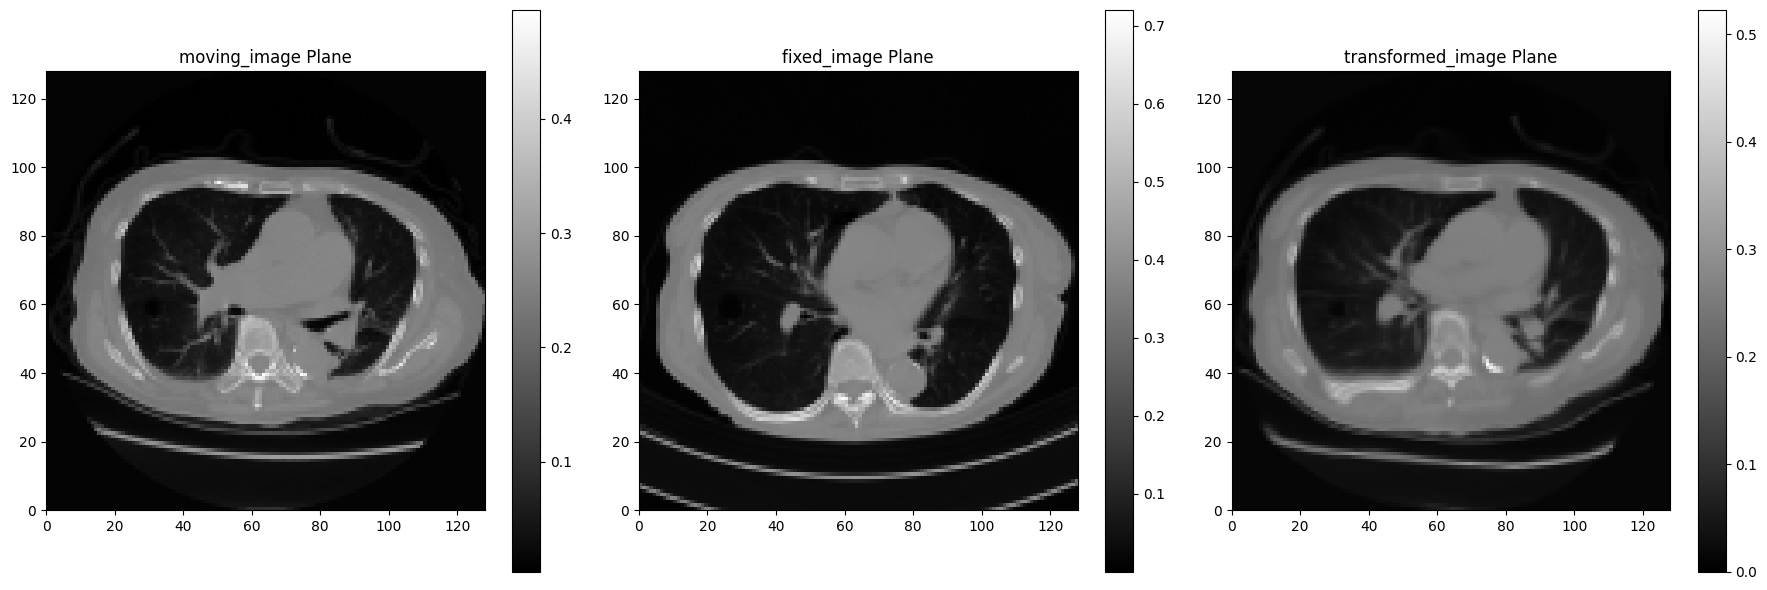

In [32]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 32

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [37]:
def dice_coefficient(img1, img2):
    intersection = np.logical_and(img1, img2)
    return 2.0 * intersection.sum() / (img1.sum() + img2.sum())

def jaccard_coefficient(img1, img2):
    intersection = np.logical_and(img1, img2)
    union = np.logical_or(img1, img2)
    return intersection.sum() / union.sum()

# 画像を2値化（任意のしきい値でしきい値処理を行う）
threshold = 0.2  # しきい値（任意の値を設定してください）
fixed_image_bin = (fixed_image > threshold).astype(int)
transformed_image_bin = (transformed_image > threshold).astype(int)

# Dice係数とJaccard係数を計算
dice = dice_coefficient(fixed_image_bin, transformed_image_bin)
print(f"Dice係数: {dice}")
jaccard = jaccard_coefficient(fixed_image_bin, transformed_image_bin)
print(f"Jaccard係数: {jaccard}")

Dice係数: 0.8701195684317002
Jaccard係数: 0.7700988034848559


In [33]:
# imsave('moving_image_Tu.tif', moving_image)
# imsave('fixed_image_Tu.tif', fixed_image)
imsave('transformed_image_Tu.tif', transformed_image)

C:\Users\user\AppData\Local\Temp\ipykernel_20740\3924875858.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('transformed_image_Tu.tif', transformed_image)


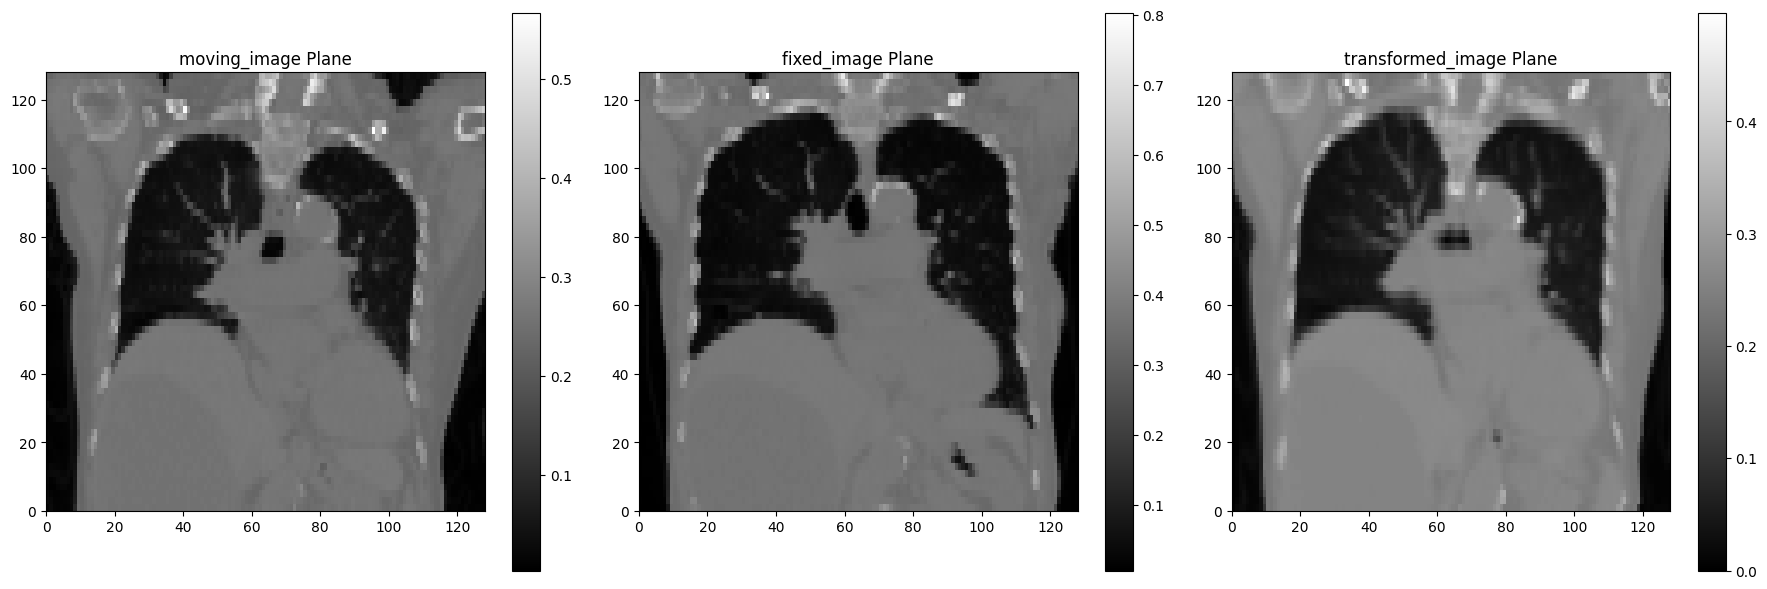

In [24]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 64

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, :, i, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, :, i, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, :, i, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()